## 1. Import Libraries and Load Cleaned Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [17]:
df = pd.read_csv('dataset/avocado_Cleaning.csv')
df_x = df.drop(columns='AveragePrice')
df_y = df['AveragePrice']

In [18]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 9230 samples
Test set: 2308 samples


## 2. Feature Scaling

In [19]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## 3.Pipeline All Models Regression

In [20]:
n = 15
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [21]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
3,Random Forest Regressor,0.8391,0.1004,0.0198,0.1407
5,XGBoost Regressor,0.8066,0.1150,0.0238,0.1542
4,Gradient Boosting Regressor,0.6984,0.1480,0.0371,0.1926
1,Ridge Regression,0.3844,0.2191,0.0757,0.2751
0,Linear Regression,0.3821,0.2193,0.0760,0.2757
2,Lasso Regression,0.0343,0.2793,0.1188,0.3446


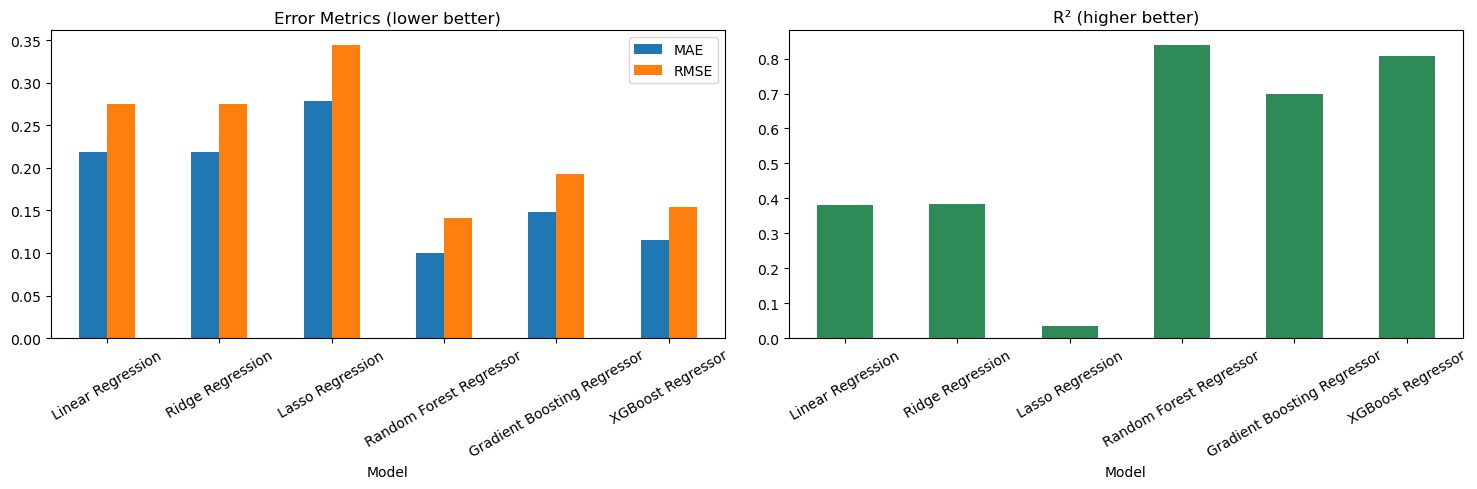

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [23]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
3,Random Forest Regressor,0.830717,0.105292,0.021676,0.147229
5,XGBoost Regressor,0.811009,0.115994,0.024201,0.155566
4,Gradient Boosting Regressor,0.692382,0.152440,0.039396,0.198485
1,Ridge Regression,0.375579,0.223951,0.079954,0.282762
0,Linear Regression,0.375447,0.223962,0.079970,0.282790
2,Lasso Regression,0.035921,0.285359,0.123380,0.351255


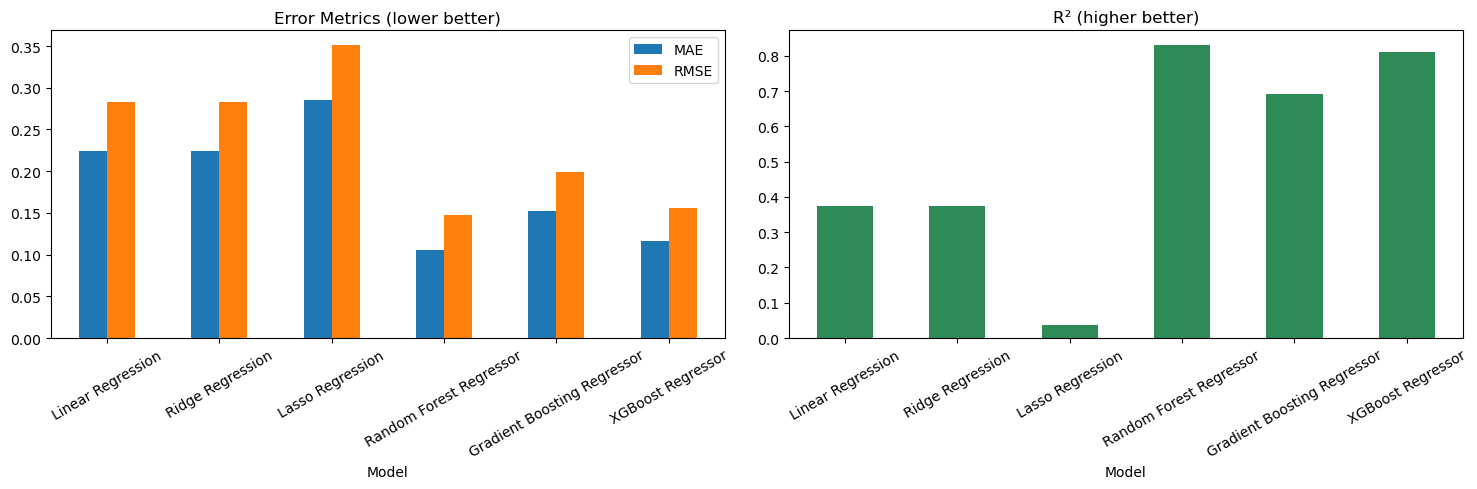

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

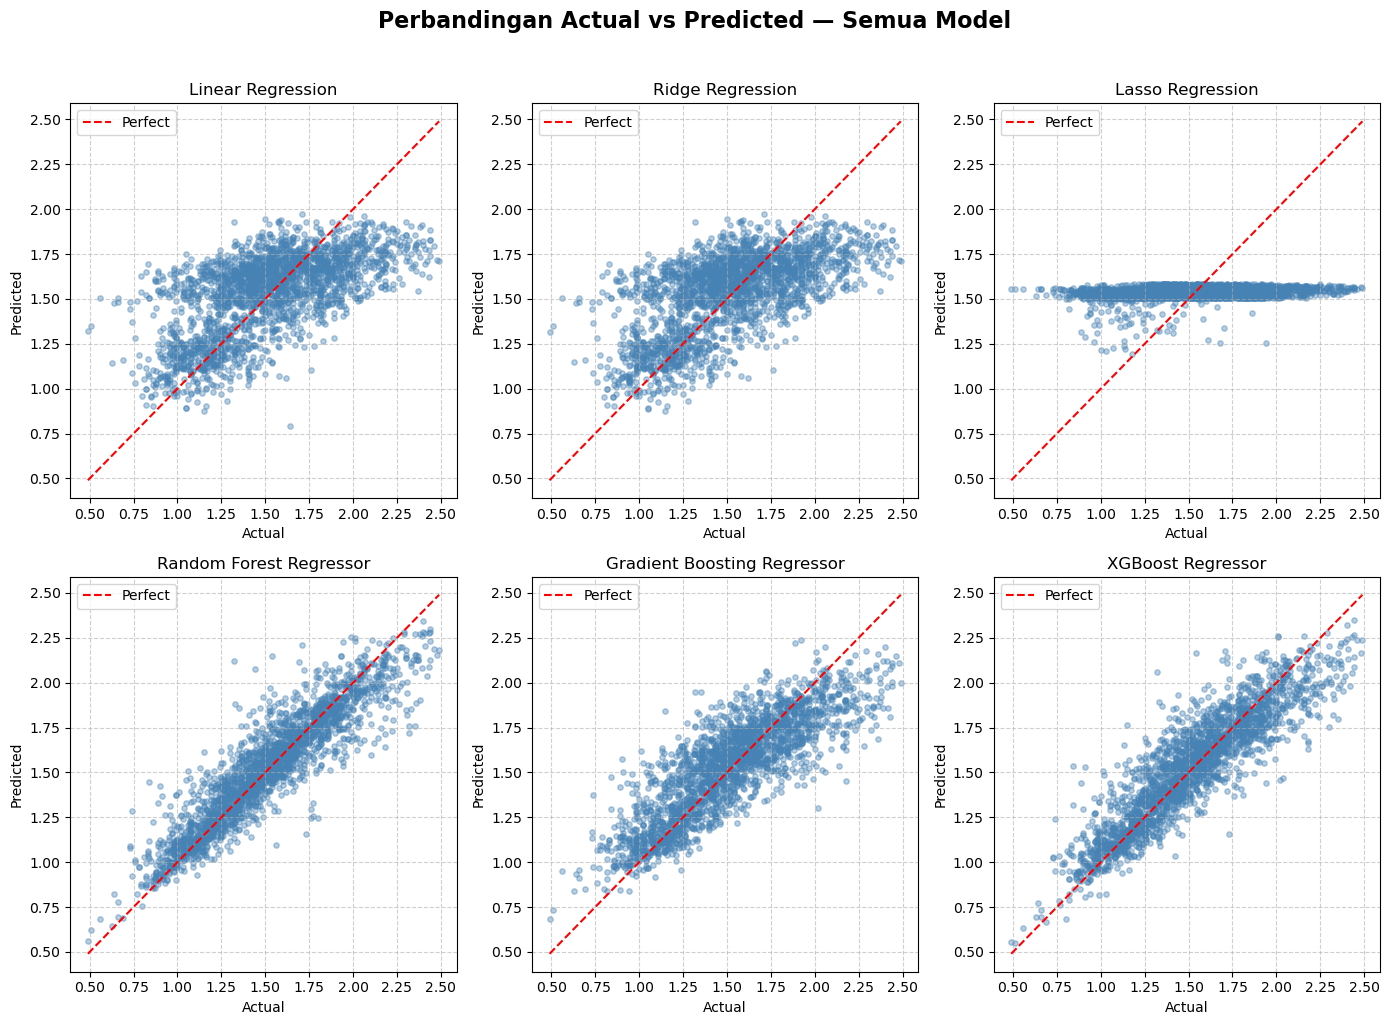

In [25]:
plot_all_modelsRegression_predictions( models_dict=regresi_pipelines, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,)

## 7. Importance Feature for Models

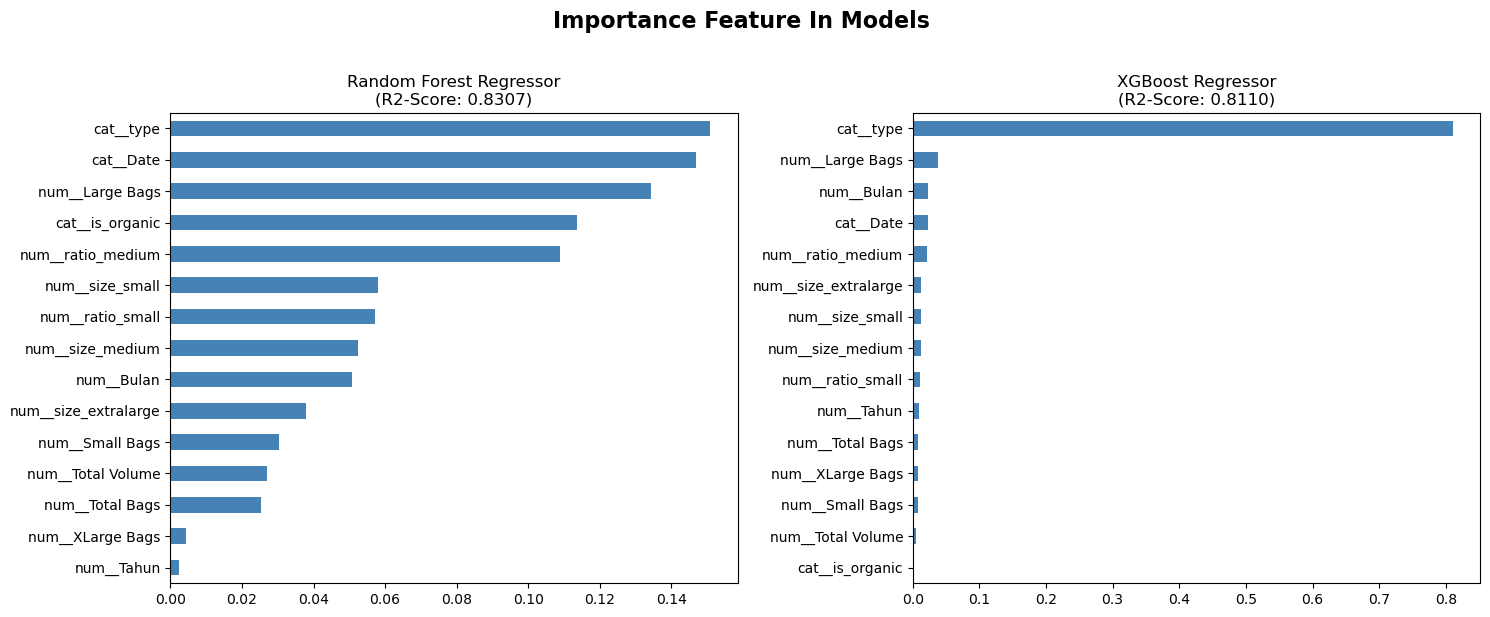

In [26]:
feature_importance(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines)

## 8. Analysis Residuals — Best Model

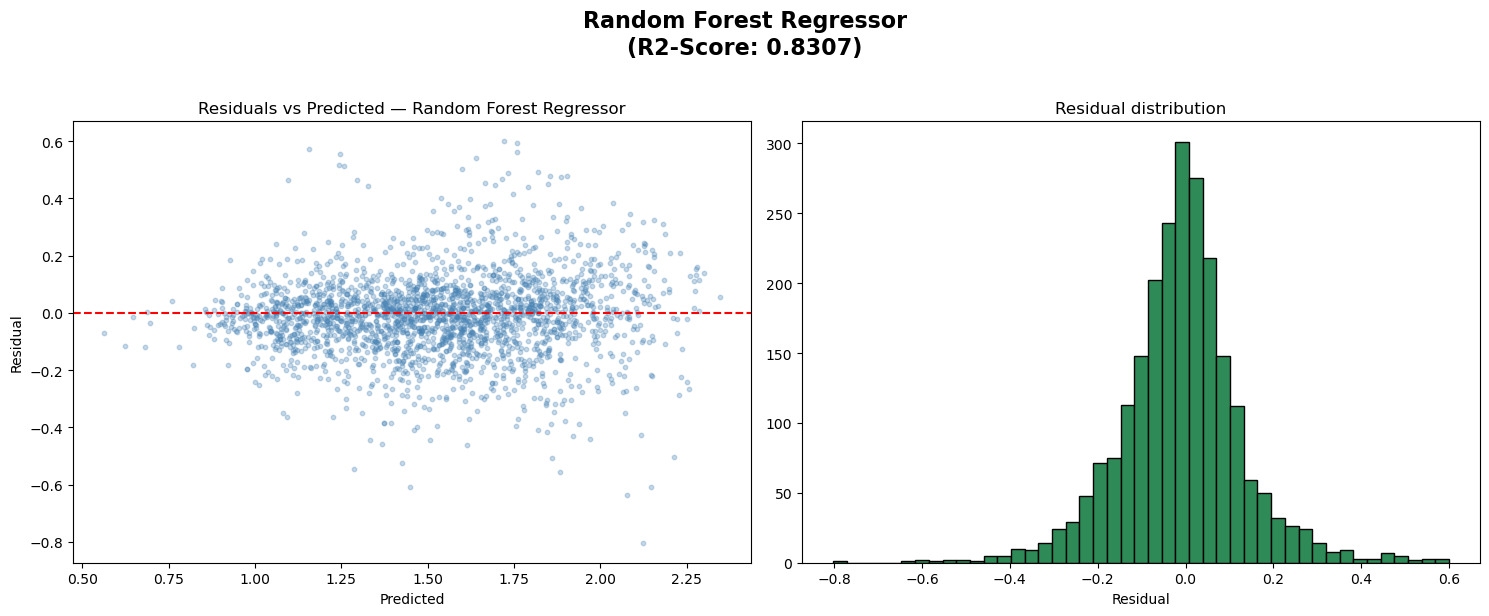

In [27]:
plot_residuals(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines,x_test=X_test,y_test=y_test)

## 9. Hyperparameter Tuning — Best Performer

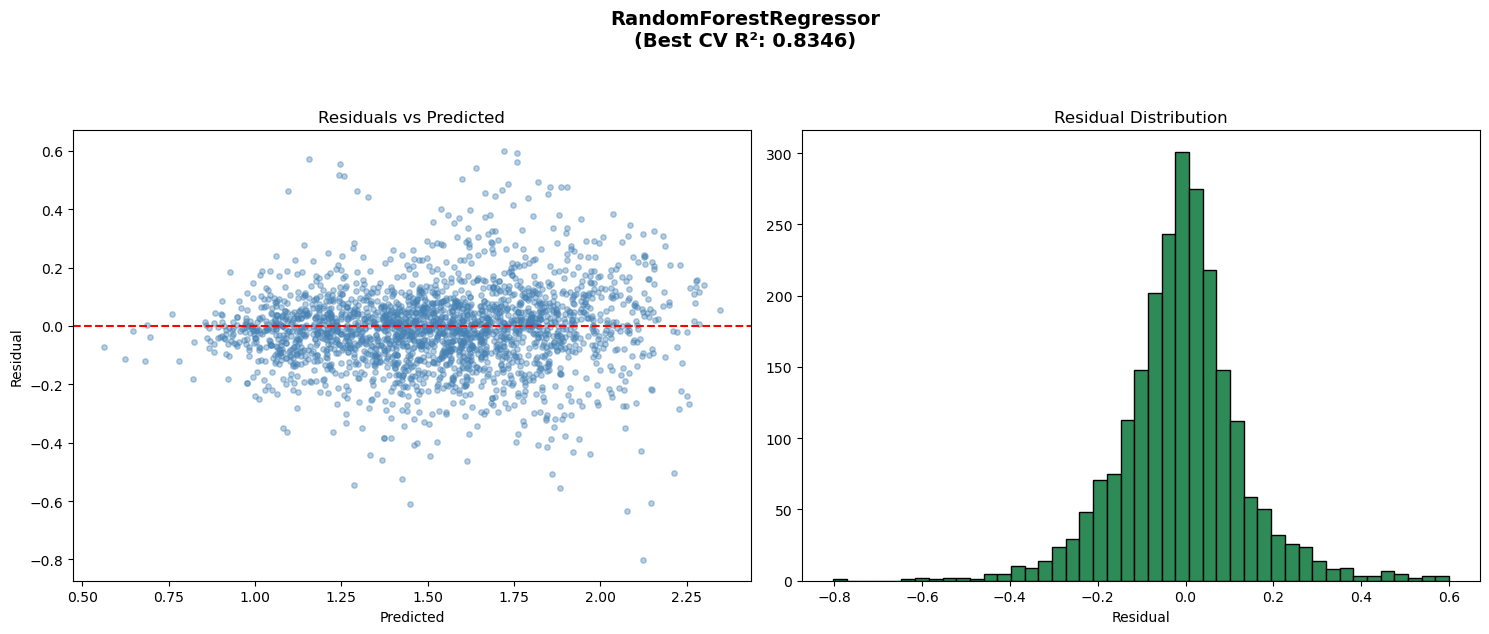

In [28]:
pipeline_model = regresi_pipelines['Random Forest Regressor']
params = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__bootstrap': [True, False]
}
best_model = Hyperparameter_Tuning(method='randomcv',pipeline_model=pipeline_model,cv=5,type_model='regression',
                                   param=params,x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test)

## 10. Tuned Model — Feature Importance

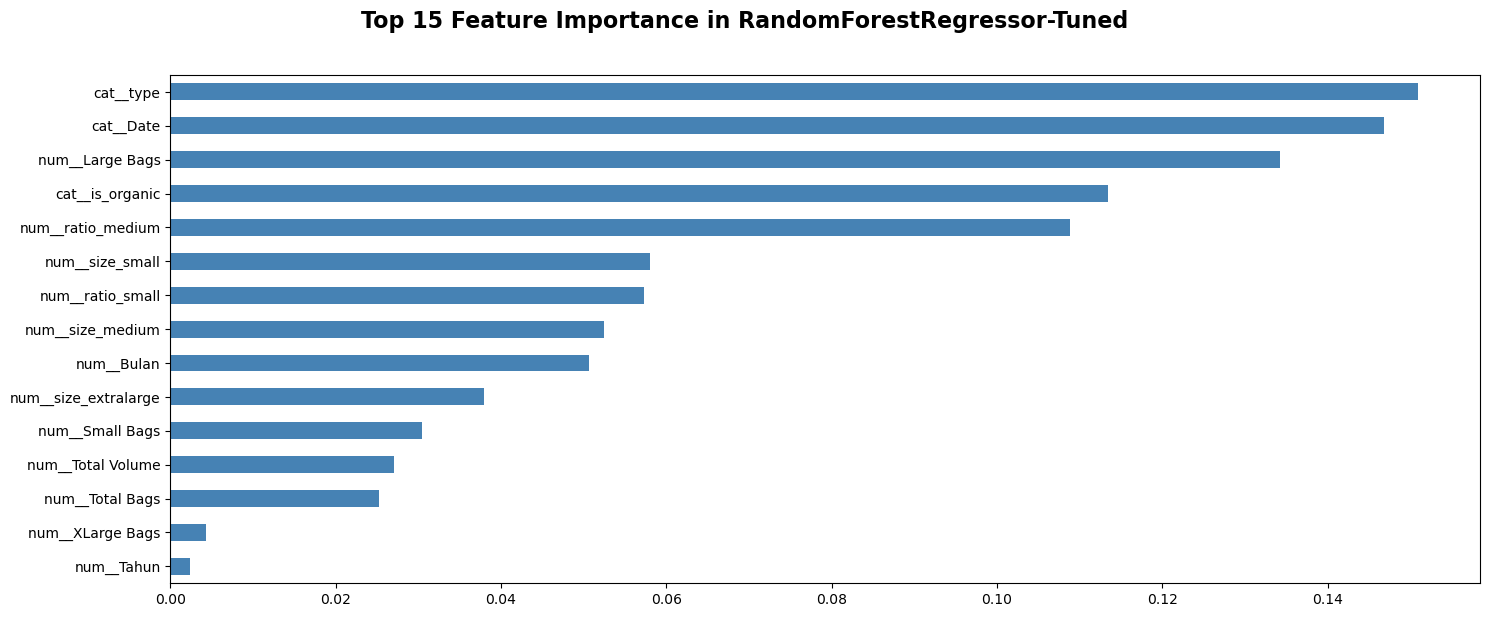

In [29]:
plot_tuned_feature_importance(tuned_model=best_model)

## 11. Simple Prediction

In [31]:
sample = X_test.iloc[:7].copy()
preds = best_model.predict(sample)

result = pd.DataFrame({'Predicted' : preds.round(2),
                       'Actual': y_test.iloc[:7].values.round(2)})
result['AbsError'] = (result['Predicted'] - result['Actual']).abs().round(2)
result

,Predicted,Actual,AbsError
0,1.81,1.75,0.06
1,1.06,1.06,0.00
2,1.32,1.23,0.09
3,1.44,1.53,0.09
4,1.97,2.14,0.17
5,1.36,1.30,0.06
6,1.88,2.36,0.48


## 12. Save Model

In [32]:
with open('Avocado_Price_Prediction', 'wb') as f:
    pickle.dump(best_model, f)